<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/U_Net_Prediction_Threshold_Sensitivity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV-UNET-004 — Prediction Threshold Sensitivity Analysis

**Experiment ID:** CV-UNET-004

This experiment evaluates the effect of different prediction thresholds
on the segmentation performance of the trained CV-UNET-003 BCE model.

No model retraining is performed.

## Imports and setup

In [1]:
import sys
import json
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch version: 2.11.0+cu128
Device: cuda


## Project setup

In [2]:
!git clone https://github.com/krithi-ks/PetroVision.git
%cd PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)


Cloning into 'PetroVision'...
remote: Enumerating objects: 201, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 201 (delta 67), reused 70 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (201/201), 9.71 MiB | 21.75 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/content/PetroVision
Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


In [3]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/PetroVision")
DRIVE_ROOT = Path("/content/drive/MyDrive/PetroVision")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Drive root:", DRIVE_ROOT)

Mounted at /content/drive
Project root: /content/PetroVision
Drive root: /content/drive/MyDrive/PetroVision


In [5]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)


Dataset extracted to: /content/PetroVision/data/lados


## Load the same test dataset

In [6]:
from torch.utils.data import DataLoader
from src.vision.lados_dataset import LADOSDataset

DATASET_ROOT = PROJECT_ROOT / "data" / "lados"

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16

test_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))

Test samples: 343
Test batches: 22


## Load CV-UNET-003

In [7]:
from src.vision.unet import UNet

MODEL_PATH = DRIVE_ROOT / "models" / "cv_unet_003_best.pt"

model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Loaded:", MODEL_PATH)

Loaded: /content/drive/MyDrive/PetroVision/models/cv_unet_003_best.pt


## Collect model probabilities

In [8]:
all_probabilities = []
all_targets = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        all_probabilities.append(
            probabilities.cpu()
        )

        all_targets.append(
            masks.cpu()
        )

all_probabilities = torch.cat(all_probabilities, dim=0)
all_targets = torch.cat(all_targets, dim=0)

print("Probability tensor:", all_probabilities.shape)
print("Target tensor:", all_targets.shape)

Probability tensor: torch.Size([343, 1, 256, 256])
Target tensor: torch.Size([343, 1, 256, 256])


## Threshold evaluation function

In [9]:
def evaluate_threshold(probabilities, targets, threshold):
    predictions = (probabilities >= threshold).float()
    targets = (targets >= 0.5).float()

    tp = ((predictions == 1) & (targets == 1)).sum().item()
    fp = ((predictions == 1) & (targets == 0)).sum().item()
    fn = ((predictions == 0) & (targets == 1)).sum().item()
    tn = ((predictions == 0) & (targets == 0)).sum().item()

    iou_denominator = tp + fp + fn
    dice_denominator = 2 * tp + fp + fn
    precision_denominator = tp + fp
    recall_denominator = tp + fn
    accuracy_denominator = tp + fp + fn + tn

    iou = tp / iou_denominator if iou_denominator else 0.0
    dice = (2 * tp) / dice_denominator if dice_denominator else 0.0
    precision = tp / precision_denominator if precision_denominator else 0.0
    recall = tp / recall_denominator if recall_denominator else 0.0
    accuracy = (
        (tp + tn) / accuracy_denominator
        if accuracy_denominator else 0.0
    )

    return {
        "threshold": threshold,
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

## Evaluate thresholds

In [10]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = [
    evaluate_threshold(
        all_probabilities,
        all_targets,
        threshold
    )
    for threshold in thresholds
]

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.style.format({
        "threshold": "{:.2f}",
        "IoU": "{:.6f}",
        "Dice": "{:.6f}",
        "Precision": "{:.6f}",
        "Recall": "{:.6f}",
        "Accuracy": "{:.6f}",
        "TP": "{:,.0f}",
        "FP": "{:,.0f}",
        "FN": "{:,.0f}",
        "TN": "{:,.0f}"
    })
)

,threshold,IoU,Dice,Precision,Recall,Accuracy,TP,FP,FN,TN
0,0.30,0.666005,0.799523,0.717731,0.902356,0.759053,"10,800,212","4,247,511","1,168,691","6,262,434"
1,0.40,0.669669,0.802158,0.763477,0.844967,0.778074,"10,113,324","3,133,071","1,855,579","7,376,874"
2,0.50,0.651780,0.789185,0.804084,0.774828,0.779586,"9,273,837","2,259,583","2,695,066","8,250,362"
3,0.60,0.617532,0.763548,0.836722,0.702144,0.768451,"8,403,898","1,639,942","3,565,005","8,870,003"
4,0.70,0.555727,0.714427,0.869781,0.606160,0.741979,"7,255,068","1,086,191","4,713,835","9,423,754"


## Metric curves

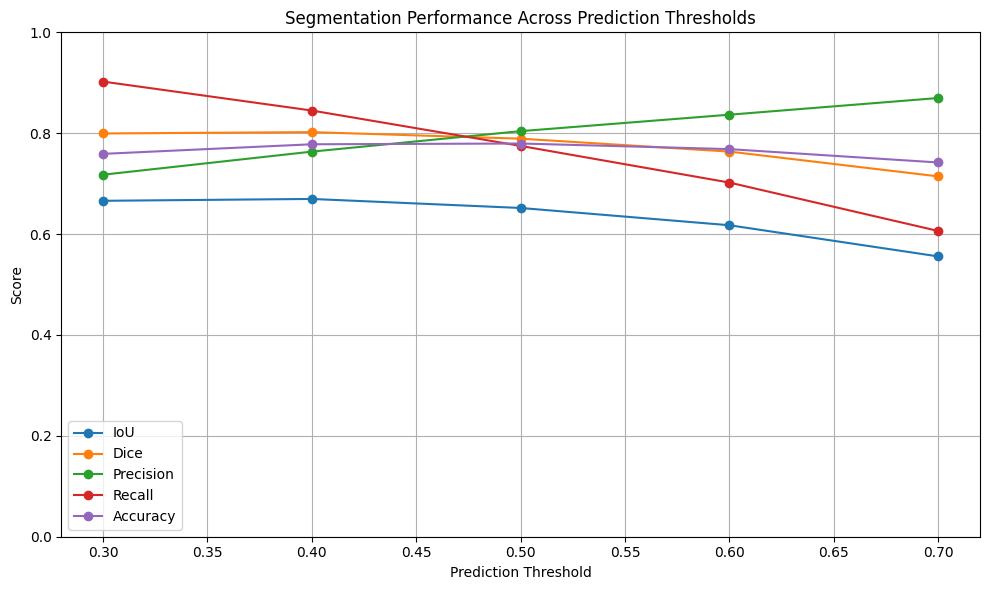

In [11]:
plt.figure(figsize=(10, 6))

for metric in ["IoU", "Dice", "Precision", "Recall", "Accuracy"]:
    plt.plot(
        threshold_df["threshold"],
        threshold_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Segmentation Performance Across Prediction Thresholds")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Precision–Recall trade-off

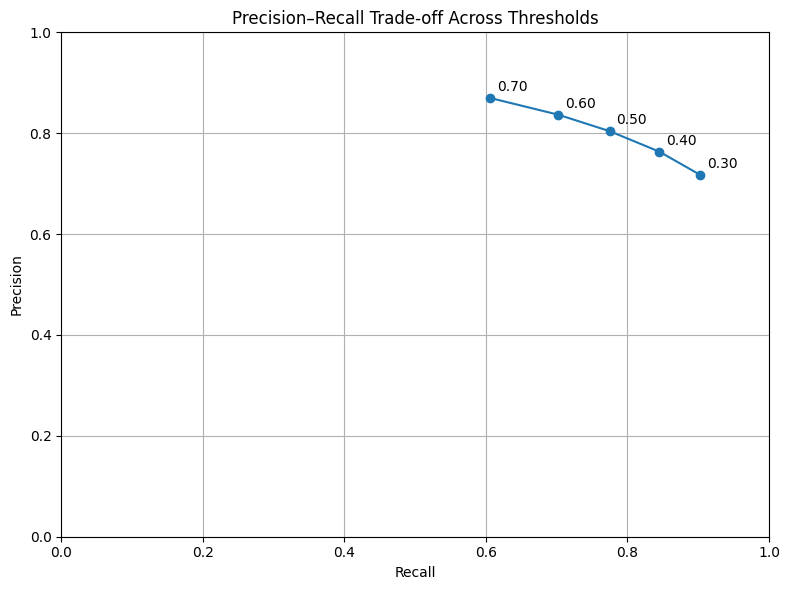

In [12]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Recall"],
    threshold_df["Precision"],
    marker="o"
)

for _, row in threshold_df.iterrows():
    plt.annotate(
        f"{row['threshold']:.2f}",
        (row["Recall"], row["Precision"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Trade-off Across Thresholds")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

## Pixel-level comparison

In [13]:
error_df = threshold_df[
    ["threshold", "TP", "FP", "FN", "TN"]
].copy()

display(error_df)

,threshold,TP,FP,FN,TN
0,0.3,10800212,4247511,1168691,6262434
1,0.4,10113324,3133071,1855579,7376874
2,0.5,9273837,2259583,2695066,8250362
3,0.6,8403898,1639942,3565005,8870003
4,0.7,7255068,1086191,4713835,9423754


## Save the actual experiment results

In [14]:
OUTPUT_DIR = DRIVE_ROOT / "results" / "cv_unet_004"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results_path = OUTPUT_DIR / "threshold_results.json"

with open(results_path, "w") as f:
    json.dump(
        threshold_results,
        f,
        indent=2
    )

print("Saved:", results_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_unet_004/threshold_results.json


## Save CSV for analysis

In [15]:
csv_path = OUTPUT_DIR / "threshold_results.csv"

threshold_df.to_csv(
    csv_path,
    index=False
)

print("Saved:", csv_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_unet_004/threshold_results.csv


## Automatically identify metric-wise threshold values

In [16]:
metric_names = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

for metric in metric_names:
    best_row = threshold_df.loc[
        threshold_df[metric].idxmax()
    ]

    print(
        f"{metric}: "
        f"threshold={best_row['threshold']:.2f}, "
        f"value={best_row[metric]:.6f}"
    )

IoU: threshold=0.40, value=0.669669
Dice: threshold=0.40, value=0.802158
Precision: threshold=0.70, value=0.869781
Recall: threshold=0.30, value=0.902356
Accuracy: threshold=0.50, value=0.779586


## Verification

In [17]:
required_files = [
    MODEL_PATH,
    OUTPUT_DIR / "threshold_results.json",
    OUTPUT_DIR / "threshold_results.csv"
]

for path in required_files:
    print(
        f"{path}:",
        "FOUND" if path.exists() else "MISSING"
    )

/content/drive/MyDrive/PetroVision/models/cv_unet_003_best.pt: FOUND
/content/drive/MyDrive/PetroVision/results/cv_unet_004/threshold_results.json: FOUND
/content/drive/MyDrive/PetroVision/results/cv_unet_004/threshold_results.csv: FOUND


## Experiment Summary

### What was tested

CV-UNET-004 evaluated the sensitivity of the trained CV-UNET-003
segmentation model to different prediction thresholds.

### Why this experiment was needed

The segmentation model produces a probability for each pixel.
The prediction threshold determines whether a pixel is classified as
petroleum contamination or background.

Changing this threshold can alter the balance between false positives
and false negatives. Therefore, threshold sensitivity should be
evaluated before selecting a threshold for later application use.

### Experimental design

The trained CV-UNET-003 BCE model was kept unchanged.

No retraining was performed. The same LADOS test set and model
predictions were evaluated using multiple thresholds.

### Evaluation

The tested thresholds were:

0.30, 0.40, 0.50, 0.60, and 0.70.

IoU, Dice, Precision, Recall, Accuracy, and pixel-level TP/FP/FN/TN
were calculated for each threshold.

### Interpretation

The experiment is intended to identify how the prediction threshold
affects segmentation behaviour and the precision–recall trade-off.

The results are specific to the evaluated CV-UNET-003 model and LADOS
test set and should not be treated as a universally optimal threshold.

In [18]:
best_iou = threshold_df.loc[threshold_df["IoU"].idxmax()]
best_dice = threshold_df.loc[threshold_df["Dice"].idxmax()]
best_precision = threshold_df.loc[threshold_df["Precision"].idxmax()]
best_recall = threshold_df.loc[threshold_df["Recall"].idxmax()]
best_accuracy = threshold_df.loc[threshold_df["Accuracy"].idxmax()]

print("=" * 70)
print("CV-UNET-004 — EXPERIMENT SUMMARY")
print("=" * 70)

print("\nPurpose:")
print(
    "Evaluate how prediction threshold changes the segmentation "
    "performance of the trained CV-UNET-003 model."
)

print("\nModel:")
print("CV-UNET-003 — BCE loss")

print("\nRetraining performed:")
print("No")

print("\nThresholds evaluated:")
print(
    ", ".join(
        f"{value:.2f}" for value in threshold_df["threshold"]
    )
)

print("\nBest observed values:")

print(
    f"  IoU       : {best_iou['IoU']:.6f} "
    f"at threshold {best_iou['threshold']:.2f}"
)

print(
    f"  Dice      : {best_dice['Dice']:.6f} "
    f"at threshold {best_dice['threshold']:.2f}"
)

print(
    f"  Precision : {best_precision['Precision']:.6f} "
    f"at threshold {best_precision['threshold']:.2f}"
)

print(
    f"  Recall    : {best_recall['Recall']:.6f} "
    f"at threshold {best_recall['threshold']:.2f}"
)

print(
    f"  Accuracy  : {best_accuracy['Accuracy']:.6f} "
    f"at threshold {best_accuracy['threshold']:.2f}"
)

print("\nMain observation:")

if best_iou["threshold"] < best_precision["threshold"]:
    print(
        "Lower thresholds produced stronger overlap/recall behaviour, "
        "while higher thresholds increased precision."
    )
else:
    print(
        "The evaluated thresholds showed a measurable change in the "
        "precision–recall behaviour."
    )

print(
    "\nInterpretation:"
    "\nThe prediction threshold has a measurable effect on segmentation "
    "performance. Within the tested range, the threshold producing the "
    "highest IoU and Dice was identified automatically from the "
    "experimental results."
)

print(
    "\nLimitation:"
    "\nThe threshold findings are specific to the evaluated model, "
    "dataset, preprocessing pipeline, and tested threshold range."
)

print(
    "\nSaved outputs:"
    f"\n- {OUTPUT_DIR / 'threshold_results.json'}"
    f"\n- {OUTPUT_DIR / 'threshold_results.csv'}"
)

CV-UNET-004 — EXPERIMENT SUMMARY

Purpose:
Evaluate how prediction threshold changes the segmentation performance of the trained CV-UNET-003 model.

Model:
CV-UNET-003 — BCE loss

Retraining performed:
No

Thresholds evaluated:
0.30, 0.40, 0.50, 0.60, 0.70

Best observed values:
  IoU       : 0.669669 at threshold 0.40
  Dice      : 0.802158 at threshold 0.40
  Precision : 0.869781 at threshold 0.70
  Recall    : 0.902356 at threshold 0.30
  Accuracy  : 0.779586 at threshold 0.50

Main observation:
Lower thresholds produced stronger overlap/recall behaviour, while higher thresholds increased precision.

Interpretation:
The prediction threshold has a measurable effect on segmentation performance. Within the tested range, the threshold producing the highest IoU and Dice was identified automatically from the experimental results.

Limitation:
The threshold findings are specific to the evaluated model, dataset, preprocessing pipeline, and tested threshold range.

Saved outputs:
- /content/

In [19]:
summary_record = {
    "experiment_id": "CV-UNET-004",
    "purpose": "Prediction threshold sensitivity analysis",
    "model": "CV-UNET-003",
    "retraining": False,
    "tested_thresholds": threshold_df["threshold"].tolist(),
    "best_iou_threshold": float(best_iou["threshold"]),
    "best_iou": float(best_iou["IoU"]),
    "best_dice_threshold": float(best_dice["threshold"]),
    "best_dice": float(best_dice["Dice"]),
    "best_precision_threshold": float(best_precision["threshold"]),
    "best_precision": float(best_precision["Precision"]),
    "best_recall_threshold": float(best_recall["threshold"]),
    "best_recall": float(best_recall["Recall"]),
    "best_accuracy_threshold": float(best_accuracy["threshold"]),
    "best_accuracy": float(best_accuracy["Accuracy"])
}

summary_path = OUTPUT_DIR / "experiment_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary_record, f, indent=2)

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_unet_004/experiment_summary.json
